In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

#postavke za grafove
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("libraries loaded")

libraries loaded


In [7]:
df=pd.read_csv("data.csv", sep=';')
print("dataset successfully loaded") 
print(f"Rows: {len(df)}")  
print(f"Columns: {len(df.columns)}") 

dataset successfully loaded
Rows: 4424
Columns: 37


In [9]:
print("="*80)
print("First 5 rows of dataset")
print("="*80)
df.head()

First 5 rows of dataset


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [13]:
print("="*80)
print("All columns in the Dataset")
print("="*80)
print(df.columns.tolist())

All columns in the Dataset
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', '

In [14]:
print("="*80)
print("Information about Dataset")
print("="*80)
df.info()

Information about Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualif

In [21]:
print("="*80)
print("Missing Values Check")
print("="*80)

missing=df.isnull().sum()
print (missing)

if missing.sum()==0:
    print("\n" + "="*80)
    print("no missing values")
    print("\n" + "="*80)

else: 
    print ("missing values: {missing.sum()}")
    print("\nColumns with missing value:")
    print(missing[missing > 0])
    

Missing Values Check
Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                         

In [24]:
print("="*80)
print("Target Variable")
print("="*80)

if 'Target' in df.columns:
    target_col='Target'
elif 'Status' in df.columns:
    target_col = 'Status'
else: 
    print("Please check the list and tell me which one is Target column")
    print(df.columns.tolist())
    target_col = None


if target_col: 
    print(f"\n Target column found: '{target_col}'")
    print(f"\nDistribution:")
    print(df[target_col].value_counts())
    print(f"\nPercentage:")
    print(df[target_col].value_counts(normalize=True).round(3) * 100)


Target Variable

 Target column found: 'Target'

Distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Percentage:
Target
Graduate    49.9
Dropout     32.1
Enrolled    17.9
Name: proportion, dtype: float64


Creating Bar Chart for Target distribution...


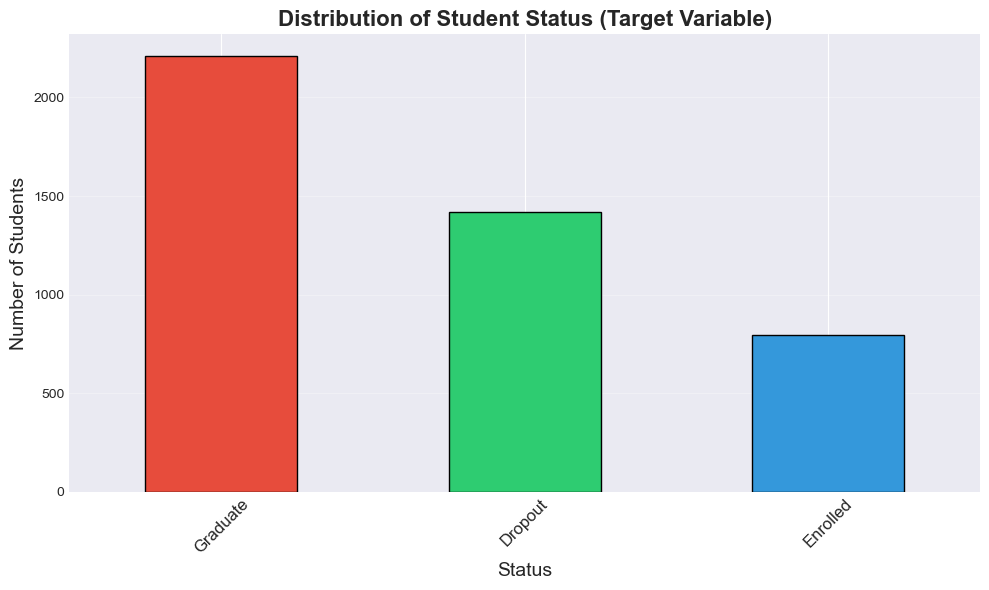

In [25]:
# BAR CHART - Distribucija Target-a
print("Creating Bar Chart for Target distribution...")
plt.figure(figsize=(10,6))
df[target_col].value_counts().plot(kind='bar', 
                                    color=['#e74c3c', '#2ecc71', '#3498db'],
                                    edgecolor='black')
plt.title('Distribution of Student Status (Target Variable)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Status', fontsize=14)
plt.ylabel('Number of Students', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

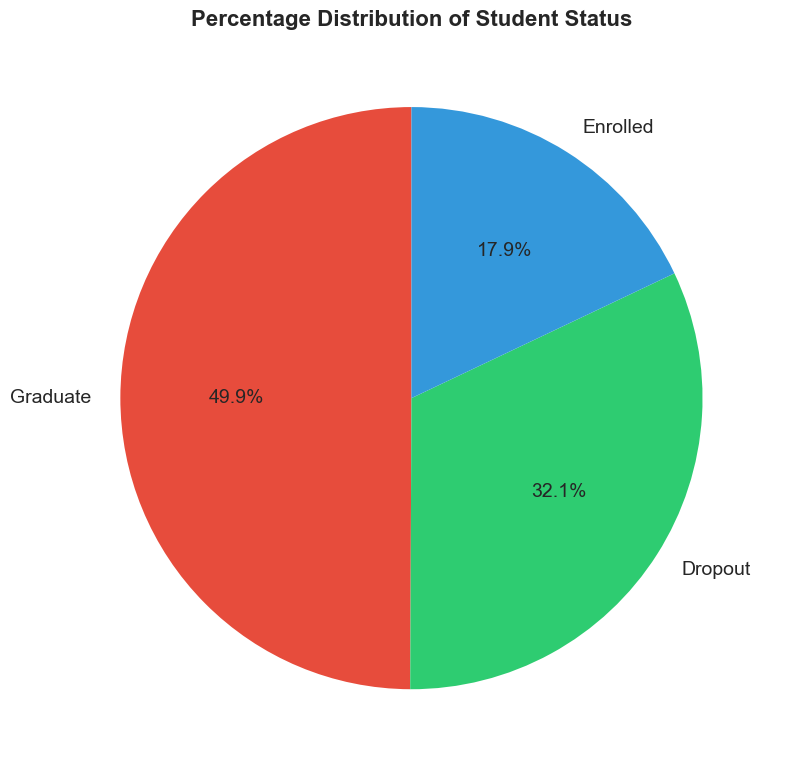

Pie chart done!


In [27]:
plt.figure(figsize=(8, 8))
colors = ['#e74c3c', '#2ecc71', '#3498db']
df[target_col].value_counts().plot(kind='pie', 
                                    autopct='%1.1f%%', 
                                    startangle=90,
                                    colors=colors,
                                    textprops={'fontsize': 14})
plt.title('Percentage Distribution of Student Status', 
          fontsize=16, fontweight='bold')
plt.ylabel('')  
plt.tight_layout()
plt.show()

print("Pie chart done!")

In [28]:
# Deskriptivna statistika
print("="*80)
print("Descriptive Statistics - Numeric Columns")
print("="*80)
df.describe()

Descriptive Statistics - Numeric Columns


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [30]:
# Extract a few interesting statistical insights
print("="*80)
print("KEY STATISTICAL INSIGHTS")
print("="*80)

# Age at enrollment
if 'Age at enrollment' in df.columns:
    print(f"Average age at enrollment: {df['Age at enrollment'].mean():.2f}")
    print(f"Youngest student: {df['Age at enrollment'].min():.0f}")
    print(f"Oldest student: {df['Age at enrollment'].max():.0f}")
    print(f"Standard deviation: {df['Age at enrollment'].std():.2f}")

print("\n" + "-"*80 + "\n")

# Admission grade
if 'Admission grade' in df.columns:
    print(f"Average admission grade: {df['Admission grade'].mean():.2f}")
    print(f"Minimum admission grade: {df['Admission grade'].min():.2f}")
    print(f"Maximum admission grade: {df['Admission grade'].max():.2f}")

print("\n" + "-"*80 + "\n")

# Previous qualification (grade)
if 'Previous qualification (grade)' in df.columns:
    print(f"Average previous qualification grade: {df['Previous qualification (grade)'].mean():.2f}")


KEY STATISTICAL INSIGHTS
Average age at enrollment: 23.27
Youngest student: 17
Oldest student: 70
Standard deviation: 7.59

--------------------------------------------------------------------------------

Average admission grade: 126.98
Minimum admission grade: 95.00
Maximum admission grade: 190.00

--------------------------------------------------------------------------------

Average previous qualification grade: 132.61


In [32]:

print("="*80)
print("Data Types")
print("="*80)

# Numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"\nNumerical columns ({len(numerical_cols)}):")
print(numerical_cols)

# Categorical columns (object type)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\n Categorical columns ({len(categorical_cols)}):")
print(categorical_cols)

Data Types

Numerical columns (36):
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation

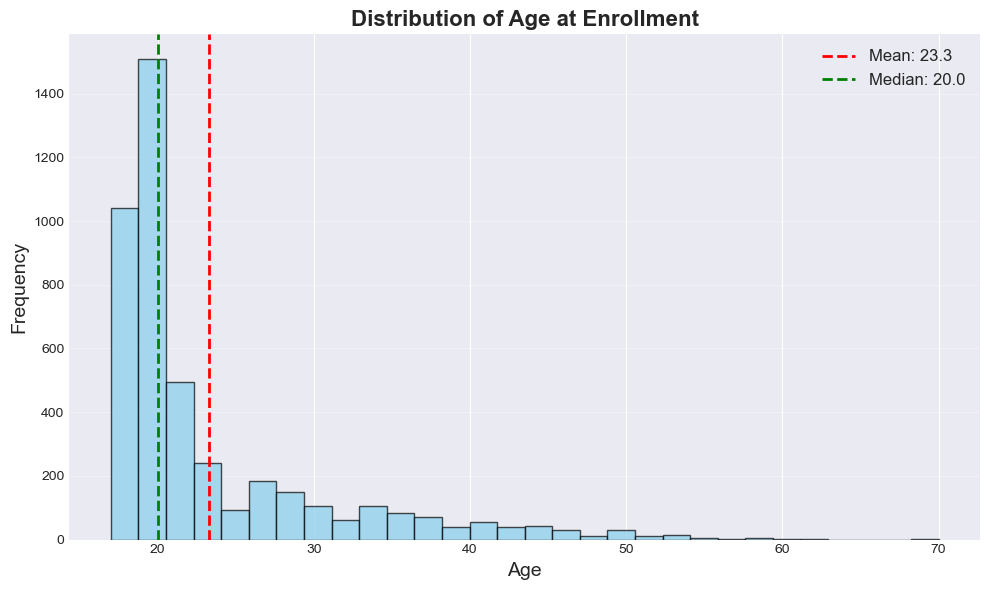

Min Age: 17
Max Age: 70
Mean Age: 23.27
Std Dev: 7.59


In [33]:
# ========================================
# Histogram - distrubution of numerical values
# ========================================

# Age at enrollment
plt.figure(figsize=(10, 6))
plt.hist(df['Age at enrollment'], bins=30, edgecolor='black', color='skyblue', alpha=0.7)
plt.axvline(df['Age at enrollment'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f"Mean: {df['Age at enrollment'].mean():.1f}")
plt.axvline(df['Age at enrollment'].median(), color='green', linestyle='--', 
            linewidth=2, label=f"Median: {df['Age at enrollment'].median():.1f}")
plt.title('Distribution of Age at Enrollment', fontsize=16, fontweight='bold')
plt.xlabel('Age', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Min Age: {df['Age at enrollment'].min()}")
print(f"Max Age: {df['Age at enrollment'].max()}")
print(f"Mean Age: {df['Age at enrollment'].mean():.2f}")
print(f"Std Dev: {df['Age at enrollment'].std():.2f}")

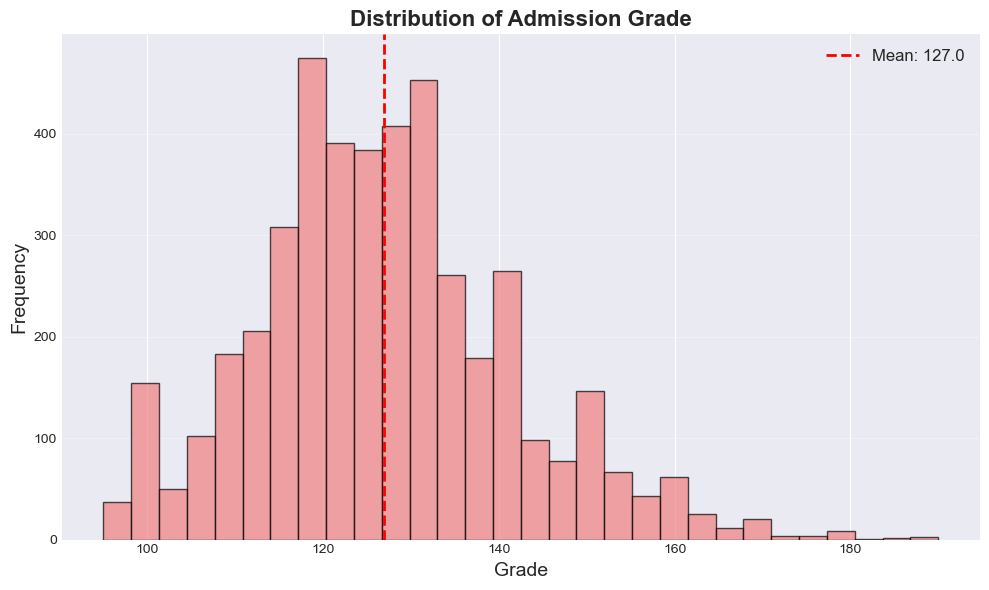

Min Grade: 95.00
Max Grade: 190.00
Mean Grade: 126.98


In [34]:
# Admission grade
plt.figure(figsize=(10, 6))
plt.hist(df['Admission grade'], bins=30, edgecolor='black', color='lightcoral', alpha=0.7)
plt.axvline(df['Admission grade'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f"Mean: {df['Admission grade'].mean():.1f}")
plt.title('Distribution of Admission Grade', fontsize=16, fontweight='bold')
plt.xlabel('Grade', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Min Grade: {df['Admission grade'].min():.2f}")
print(f"Max Grade: {df['Admission grade'].max():.2f}")
print(f"Mean Grade: {df['Admission grade'].mean():.2f}")

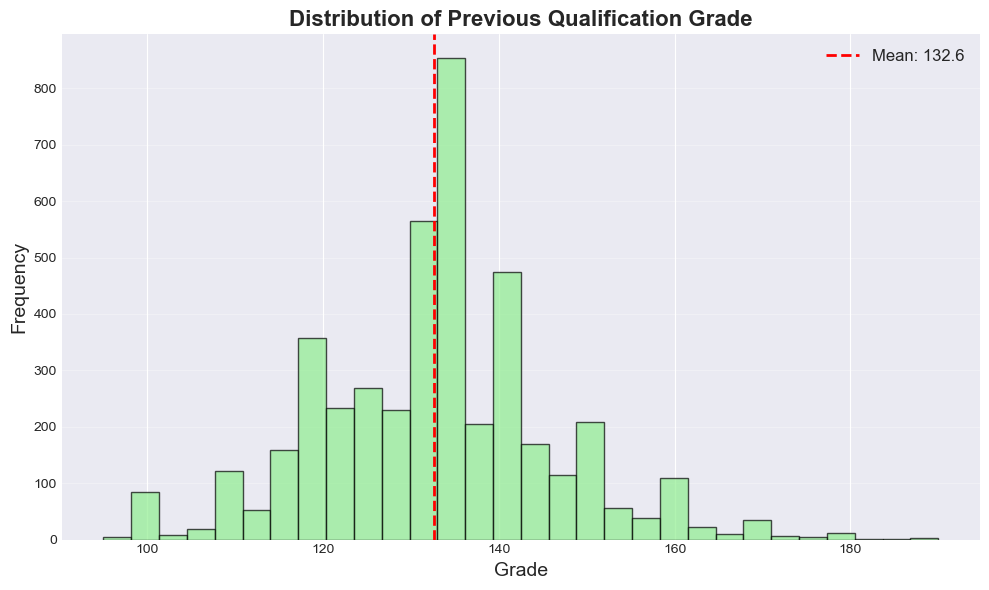

Min: 95.00
Max: 190.00
Mean: 132.61


In [35]:
# Previous qualification (grade)
plt.figure(figsize=(10, 6))
plt.hist(df['Previous qualification (grade)'], bins=30, edgecolor='black', 
         color='lightgreen', alpha=0.7)
plt.axvline(df['Previous qualification (grade)'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f"Mean: {df['Previous qualification (grade)'].mean():.1f}")
plt.title('Distribution of Previous Qualification Grade', fontsize=16, fontweight='bold')
plt.xlabel('Grade', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Min: {df['Previous qualification (grade)'].min():.2f}")
print(f"Max: {df['Previous qualification (grade)'].max():.2f}")
print(f"Mean: {df['Previous qualification (grade)'].mean():.2f}")

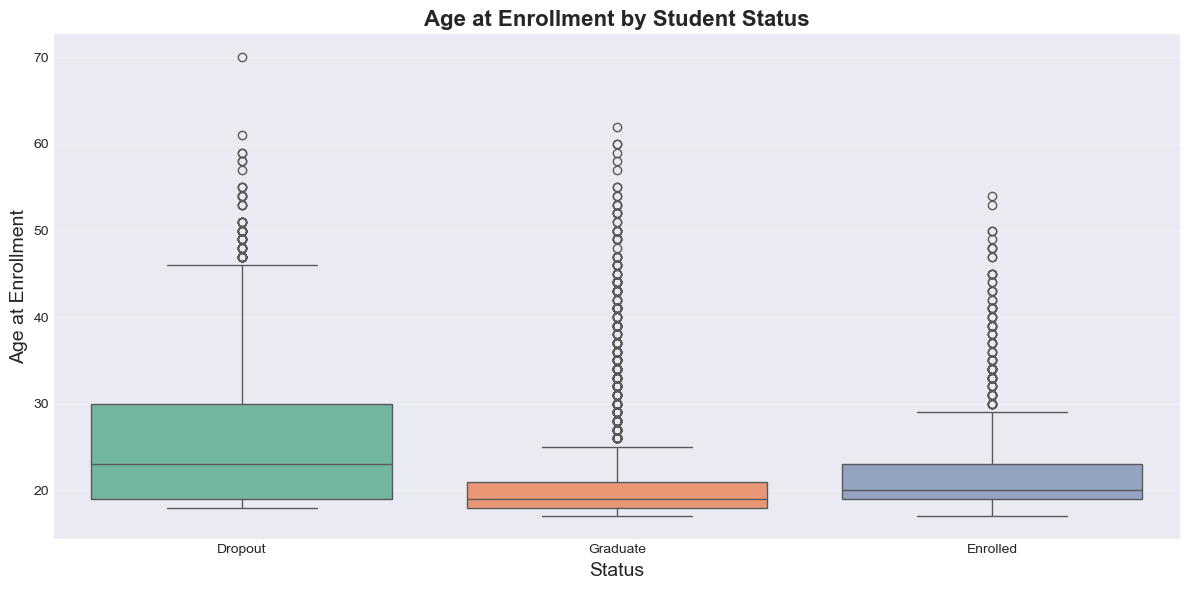

Average age by status:
Target
Dropout     26.07
Enrolled    22.37
Graduate    21.78
Name: Age at enrollment, dtype: float64


In [37]:
# ========================================
# BOX PLOTS - BIVARIATE ANALYSIS
# ========================================

# Age at enrollment vs Target
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Target', y='Age at enrollment', palette='Set2')
plt.title('Age at Enrollment by Student Status', fontsize=16, fontweight='bold')
plt.xlabel('Status', fontsize=14)
plt.ylabel('Age at Enrollment', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Mean by group
print("Average age by status:")
print(df.groupby('Target')['Age at enrollment'].mean().round(2))

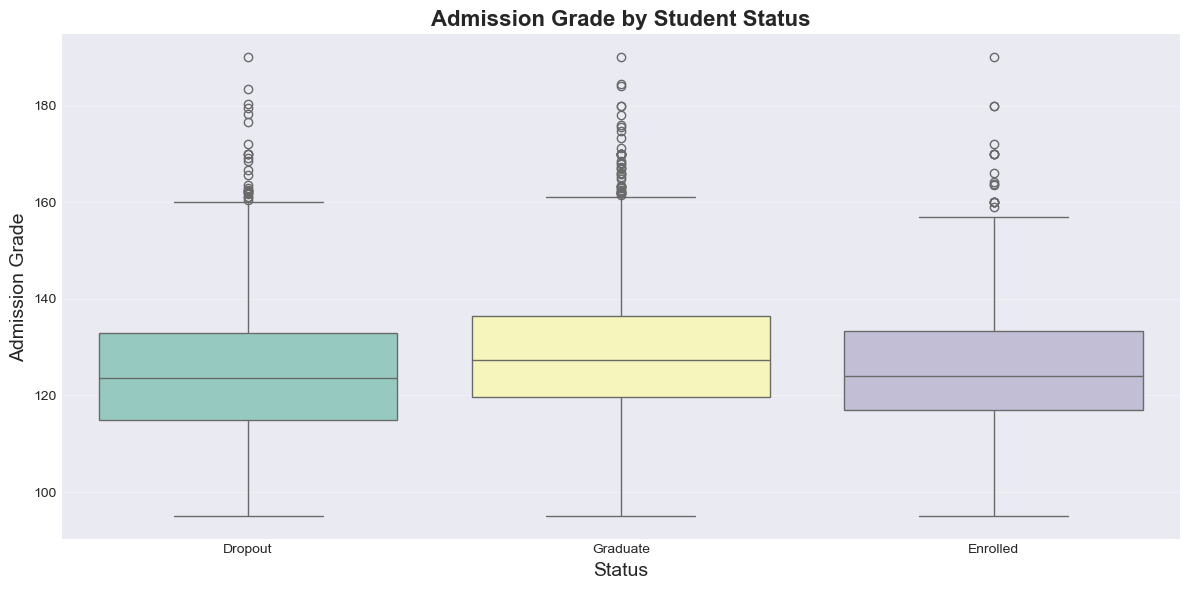

Average admission grade by statusu:
Target
Dropout     124.96
Enrolled    125.53
Graduate    128.79
Name: Admission grade, dtype: float64


In [38]:
# Admission grade vs Target
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Target', y='Admission grade', palette='Set3')
plt.title('Admission Grade by Student Status', fontsize=16, fontweight='bold')
plt.xlabel('Status', fontsize=14)
plt.ylabel('Admission Grade', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Average admission grade by statusu:")
print(df.groupby('Target')['Admission grade'].mean().round(2))

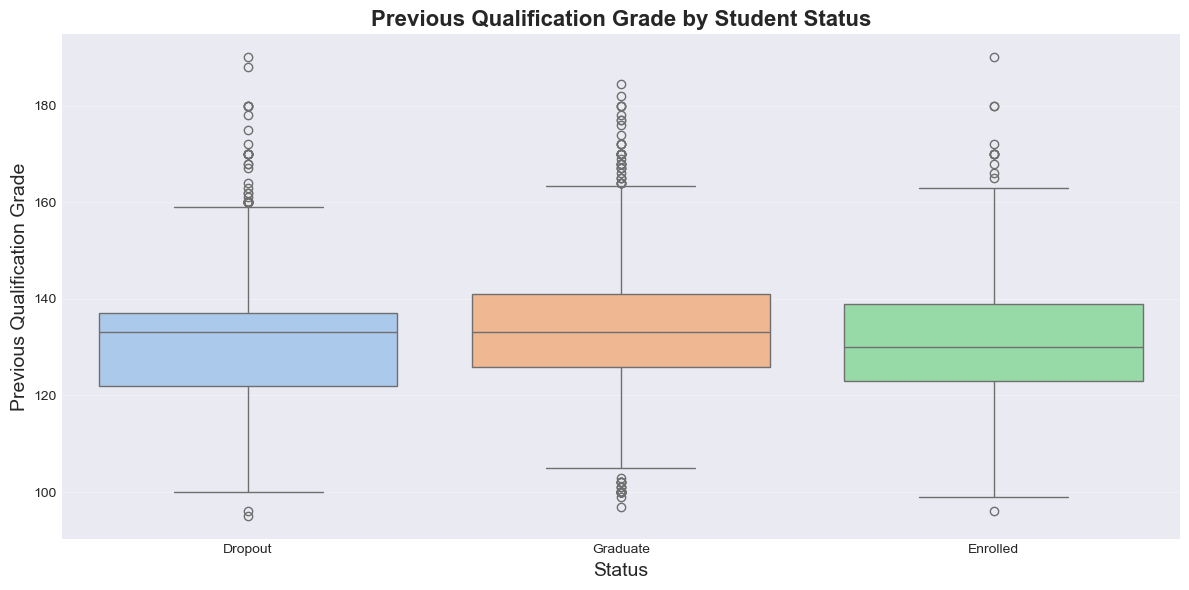

Average previous qualification by statusu:
Target
Dropout     131.11
Enrolled    131.21
Graduate    134.08
Name: Previous qualification (grade), dtype: float64


In [39]:
# Previous qualification vs Target
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Target', y='Previous qualification (grade)', palette='pastel')
plt.title('Previous Qualification Grade by Student Status', fontsize=16, fontweight='bold')
plt.xlabel('Status', fontsize=14)
plt.ylabel('Previous Qualification Grade', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Average previous qualification by statusu:")
print(df.groupby('Target')['Previous qualification (grade)'].mean().round(2))

Creating...
(This might take a while...)


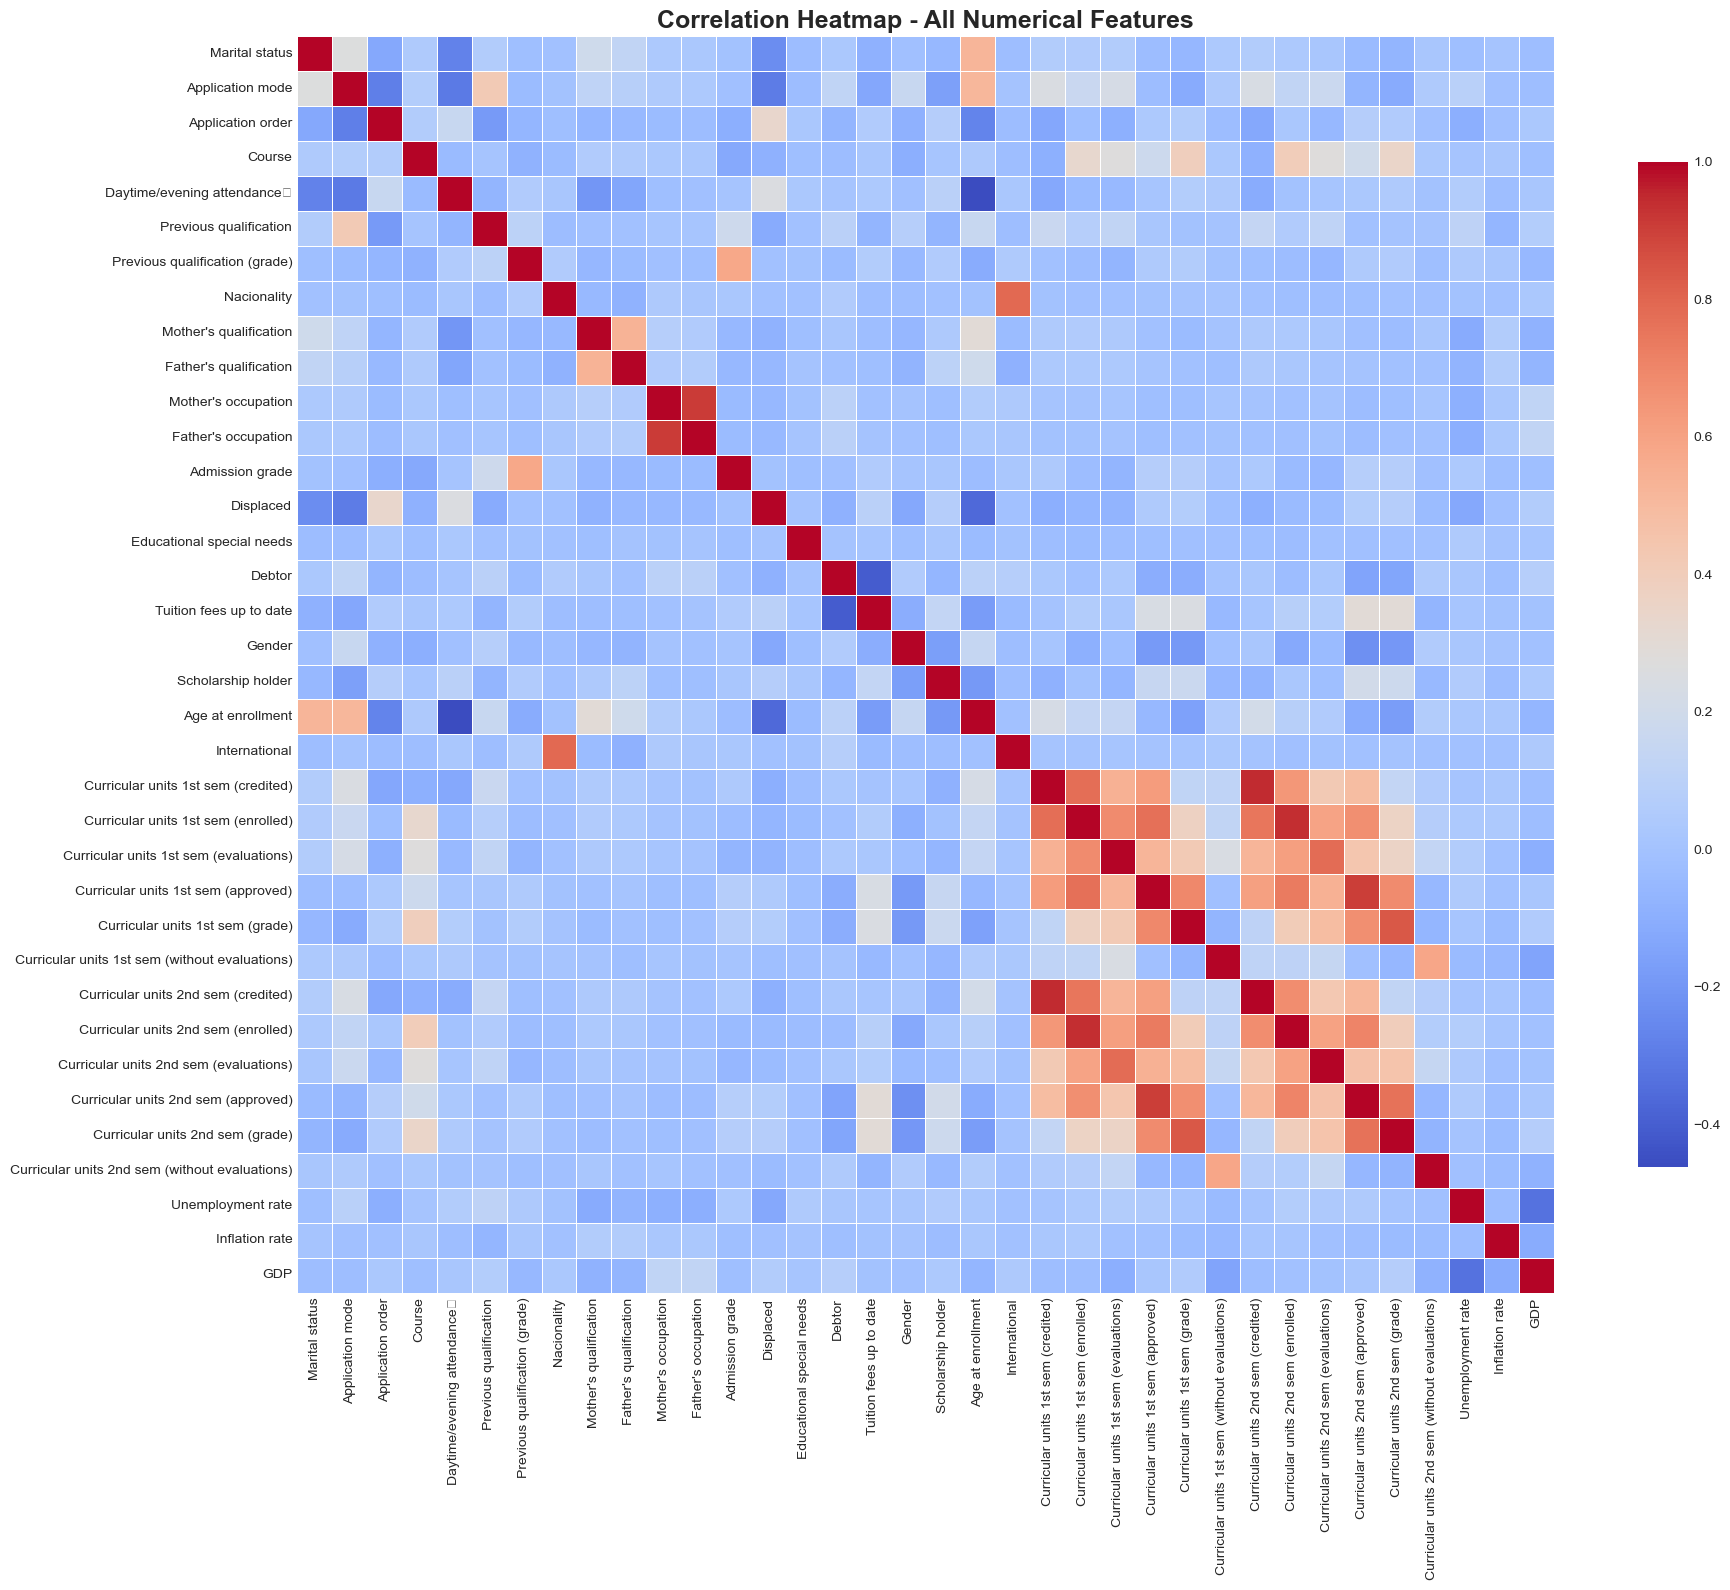

In [41]:
# ========================================
# CORRELATION HEATMAP
# ========================================

print("Creating...")
print("(This might take a while...)")

# Uzmi samo numeričke kolone
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Izračunaj correlation matrix
correlation_matrix = numerical_df.corr()

# Kreiraj heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=False, fmt='.2f', cmap='coolwarm', 
            square=True, cbar_kws={"shrink": 0.8}, linewidths=0.5)
plt.title('Correlation Heatmap - All Numerical Features', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [43]:
# Pronađi top korelacije
print("="*80)
print("Top 20 strongest correlations")
print("="*80)

# Flatten correlation matrix
corr_pairs = correlation_matrix.unstack()

# Ukloni duplicates i self-correlations
corr_pairs = corr_pairs[corr_pairs < 1]
corr_pairs = corr_pairs.drop_duplicates()

# Sortiraj po apsolutnoj vrednosti
top_corr = corr_pairs.abs().sort_values(ascending=False).head(20)

print(top_corr)

Top 20 strongest correlations
Curricular units 1st sem (credited)     Curricular units 2nd sem (credited)       0.944811
Curricular units 1st sem (enrolled)     Curricular units 2nd sem (enrolled)       0.942627
Mother's occupation                     Father's occupation                       0.910472
Curricular units 1st sem (approved)     Curricular units 2nd sem (approved)       0.904002
Curricular units 1st sem (grade)        Curricular units 2nd sem (grade)          0.837170
Nacionality                             International                             0.790935
Curricular units 1st sem (evaluations)  Curricular units 2nd sem (evaluations)    0.778863
Curricular units 1st sem (credited)     Curricular units 1st sem (enrolled)       0.774344
Curricular units 1st sem (enrolled)     Curricular units 1st sem (approved)       0.769083
Curricular units 2nd sem (approved)     Curricular units 2nd sem (grade)          0.760804
Curricular units 1st sem (enrolled)     Curricular units 2nd

In [44]:
# ========================================
# CATEGORICAL FEATURES - BAR CHARTS
# ========================================

# Prvo provjeri koje kategoričke kolone imaš
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'Target' in categorical_cols:
    categorical_cols.remove('Target')  # Ukloni target jer smo ga već analizirali

print(f"Number of categorical columns: {len(categorical_cols)}")
print("Columns:", categorical_cols)

Number of categorical columns: 0
Columns: []


In [47]:
# ========================================
# HUMAN-READABLE LABEL MAPPINGS
# ========================================

gender_map = {
    0: "Female",
    1: "Male"
}

marital_status_map = {
    1: "Single",
    2: "Married",
    3: "Widowed",
    4: "Divorced",
    5: "Civil union",
    6: "Legally separated"
}

daytime_evening_map = {
    0: "Evening",
    1: "Daytime"
}

yes_no_map = {
    0: "No",
    1: "Yes"
}

target_map = {
    "Dropout": "Dropout",
    "Enrolled": "Enrolled",
    "Graduate": "Graduate"
}

# Create helper label columns (so we can use them in plots)
if "Gender" in df.columns:
    df["Gender_label"] = df["Gender"].map(gender_map)

if "Marital status" in df.columns:
    df["Marital status_label"] = df["Marital status"].map(marital_status_map)

if "Daytime/evening attendance" in df.columns:
    df["Daytime/evening_label"] = df["Daytime/evening attendance"].map(daytime_evening_map)

if "Scholarship holder" in df.columns:
    df["Scholarship_label"] = df["Scholarship holder"].map(yes_no_map)

if "Displaced" in df.columns:
    df["Displaced_label"] = df["Displaced"].map(yes_no_map)

if "Educational special needs" in df.columns:
    df["Educational special needs_label"] = df["Educational special needs"].map(yes_no_map)

if "Debtor" in df.columns:
    df["Debtor_label"] = df["Debtor"].map(yes_no_map)

if "Tuition fees up to date" in df.columns:
    df["Tuition up to date_label"] = df["Tuition fees up to date"].map(yes_no_map)


<Figure size 1000x600 with 0 Axes>

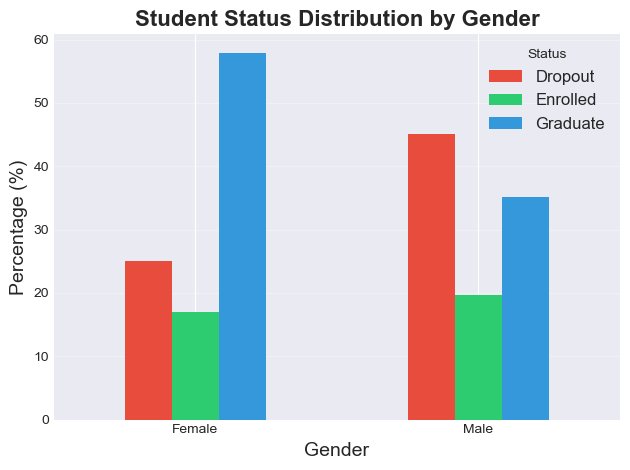

Distribution by Gender and Target (%):
Target        Dropout  Enrolled  Graduate
Gender_label                             
Female          25.10     16.98     57.91
Male            45.05     19.73     35.22


In [48]:
# ========================================
# Gender vs Target (Dropout / Enrolled / Graduate)
# ========================================
if "Gender_label" in df.columns:
    plt.figure(figsize=(10, 6))
    
    # Create pivot table: % per gender
    gender_target = pd.crosstab(df["Gender_label"], df["Target"], normalize="index") * 100
    
    gender_target.plot(kind="bar", stacked=False, color=["#e74c3c", "#2ecc71", "#3498db"])
    plt.title("Student Status Distribution by Gender", fontsize=16, fontweight="bold")
    plt.xlabel("Gender", fontsize=14)
    plt.ylabel("Percentage (%)", fontsize=14)
    plt.legend(title="Status", fontsize=12)
    plt.xticks(rotation=0)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("Distribution by Gender and Target (%):")
    print(gender_target.round(2))


<Figure size 1200x600 with 0 Axes>

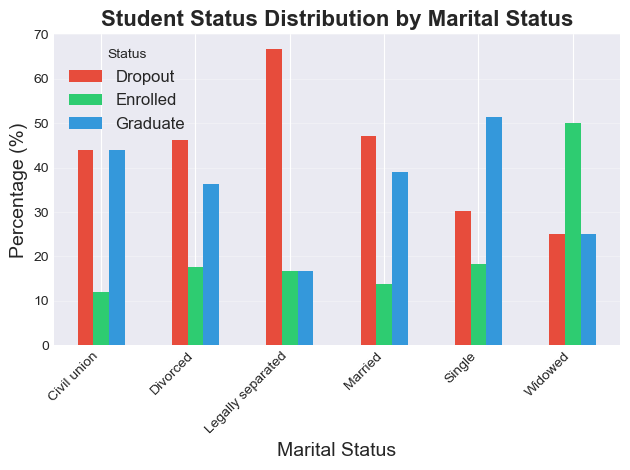

Distribution by Marital Status and Target (%):
Target                Dropout  Enrolled  Graduate
Marital status_label                             
Civil union             44.00     12.00     44.00
Divorced                46.15     17.58     36.26
Legally separated       66.67     16.67     16.67
Married                 47.23     13.72     39.05
Single                  30.21     18.37     51.42
Widowed                 25.00     50.00     25.00


In [49]:
# ========================================
# Marital Status vs Target
# ========================================
if "Marital status_label" in df.columns:
    plt.figure(figsize=(12, 6))
    
    marital_target = pd.crosstab(df["Marital status_label"], df["Target"], normalize="index") * 100
    
    marital_target.plot(kind="bar", stacked=False, color=["#e74c3c", "#2ecc71", "#3498db"])
    plt.title("Student Status Distribution by Marital Status", fontsize=16, fontweight="bold")
    plt.xlabel("Marital Status", fontsize=14)
    plt.ylabel("Percentage (%)", fontsize=14)
    plt.legend(title="Status", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("Distribution by Marital Status and Target (%):")
    print(marital_target.round(2))


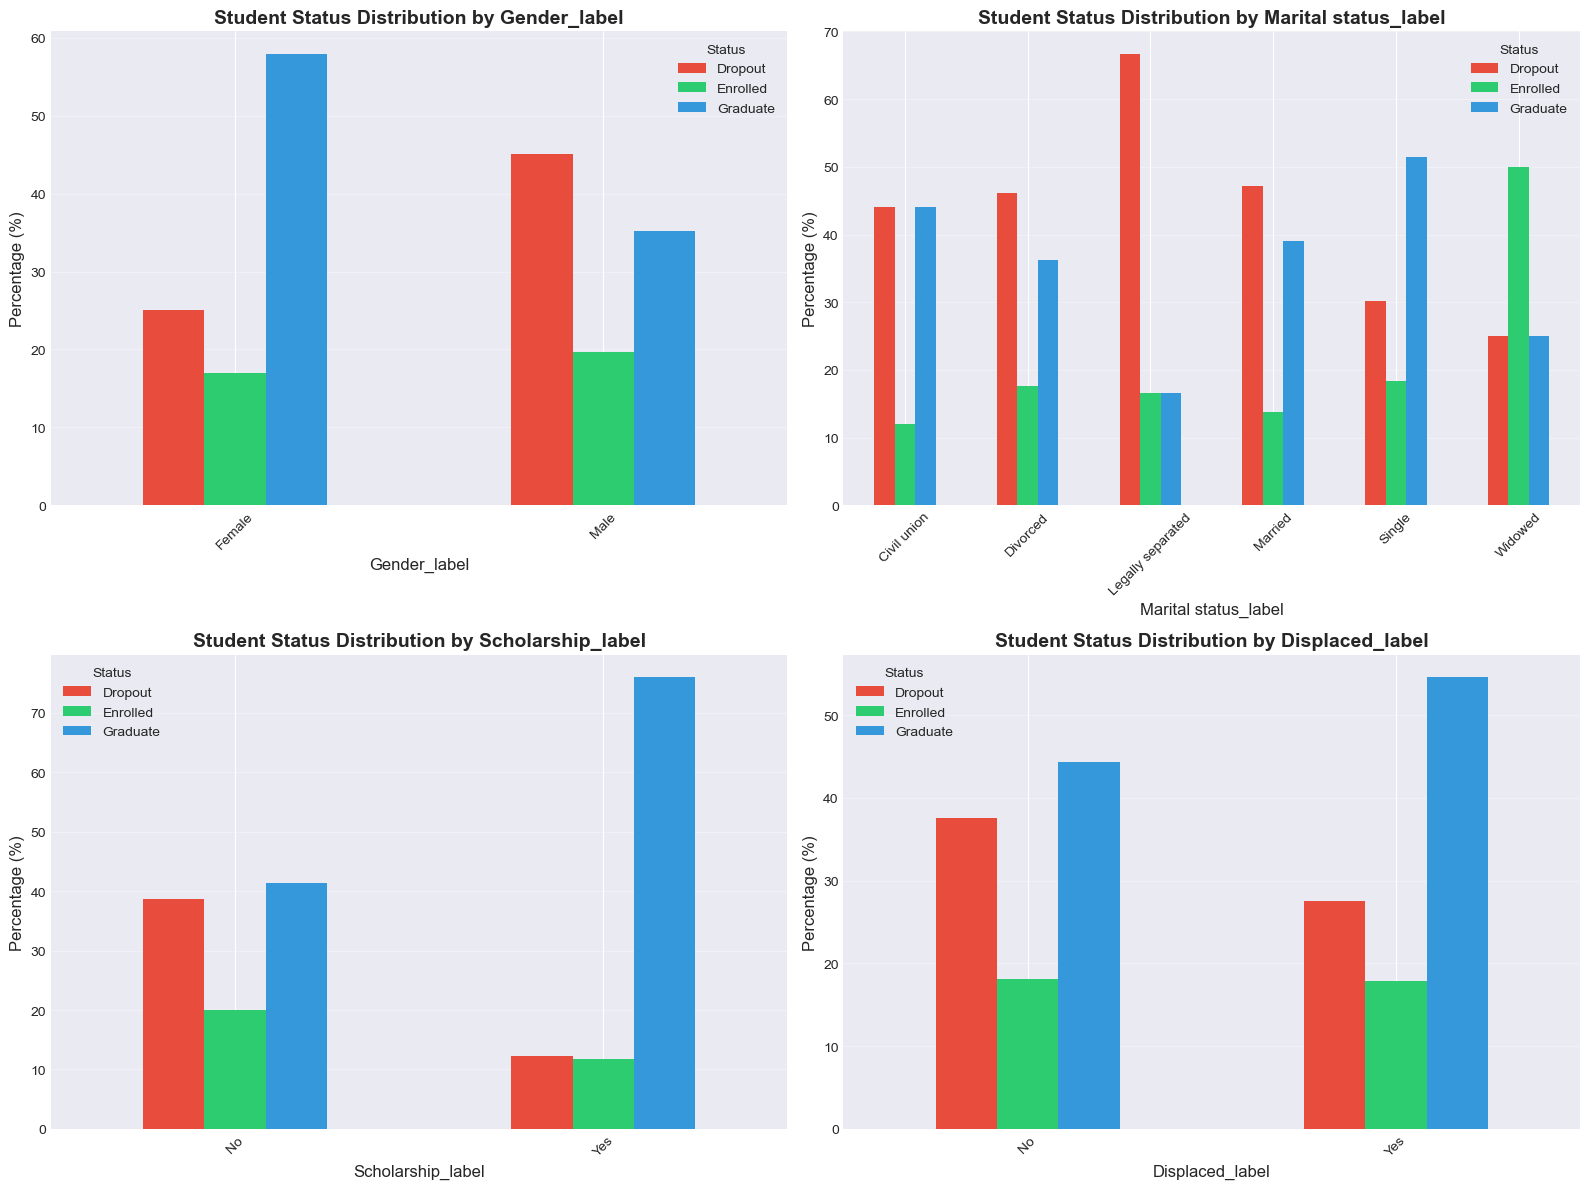

In [50]:
# ========================================
# Multiple categorical features vs Target
# ========================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Choose categorical columns (use the *_label versions where available)
cat_cols_to_plot = [
    "Gender_label",
    "Marital status_label",
    "Scholarship_label",
    "Displaced_label"
]

for idx, col in enumerate(cat_cols_to_plot):
    if col not in df.columns:
        continue
        
    row = idx // 2
    col_idx = idx % 2
    
    ct = pd.crosstab(df[col], df["Target"], normalize="index") * 100
    
    ct.plot(kind="bar", ax=axes[row, col_idx], color=["#e74c3c", "#2ecc71", "#3498db"])
    axes[row, col_idx].set_title(f"Student Status Distribution by {col}", fontsize=14, fontweight="bold")
    axes[row, col_idx].set_xlabel(col, fontsize=12)
    axes[row, col_idx].set_ylabel("Percentage (%)", fontsize=12)
    axes[row, col_idx].tick_params(axis="x", rotation=45)
    axes[row, col_idx].grid(axis="y", alpha=0.3)
    axes[row, col_idx].legend(title="Status", fontsize=10)

plt.tight_layout()
plt.show()


In [51]:
# ========================================
# OUTLIER DETECTION - IQR METHOD
# ========================================

def detect_outliers_iqr(data, column):
    """Detect outliers using the IQR method."""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    return outliers, lower_bound, upper_bound

# Detect outliers in Age at enrollment
outliers_age, lower, upper = detect_outliers_iqr(df, "Age at enrollment")

print("="*80)
print("OUTLIER DETECTION - AGE AT ENROLLMENT")
print("="*80)
print(f"Lower bound: {lower:.2f}")
print(f"Upper bound: {upper:.2f}")
print(f"Number of outliers: {len(outliers_age)} ({len(outliers_age)/len(df)*100:.2f}%)")

if len(outliers_age) > 0:
    print(f"\nOutlier ages: {sorted(outliers_age['Age at enrollment'].unique())}")


OUTLIER DETECTION - AGE AT ENROLLMENT
Lower bound: 10.00
Upper bound: 34.00
Number of outliers: 441 (9.97%)

Outlier ages: [np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(70)]


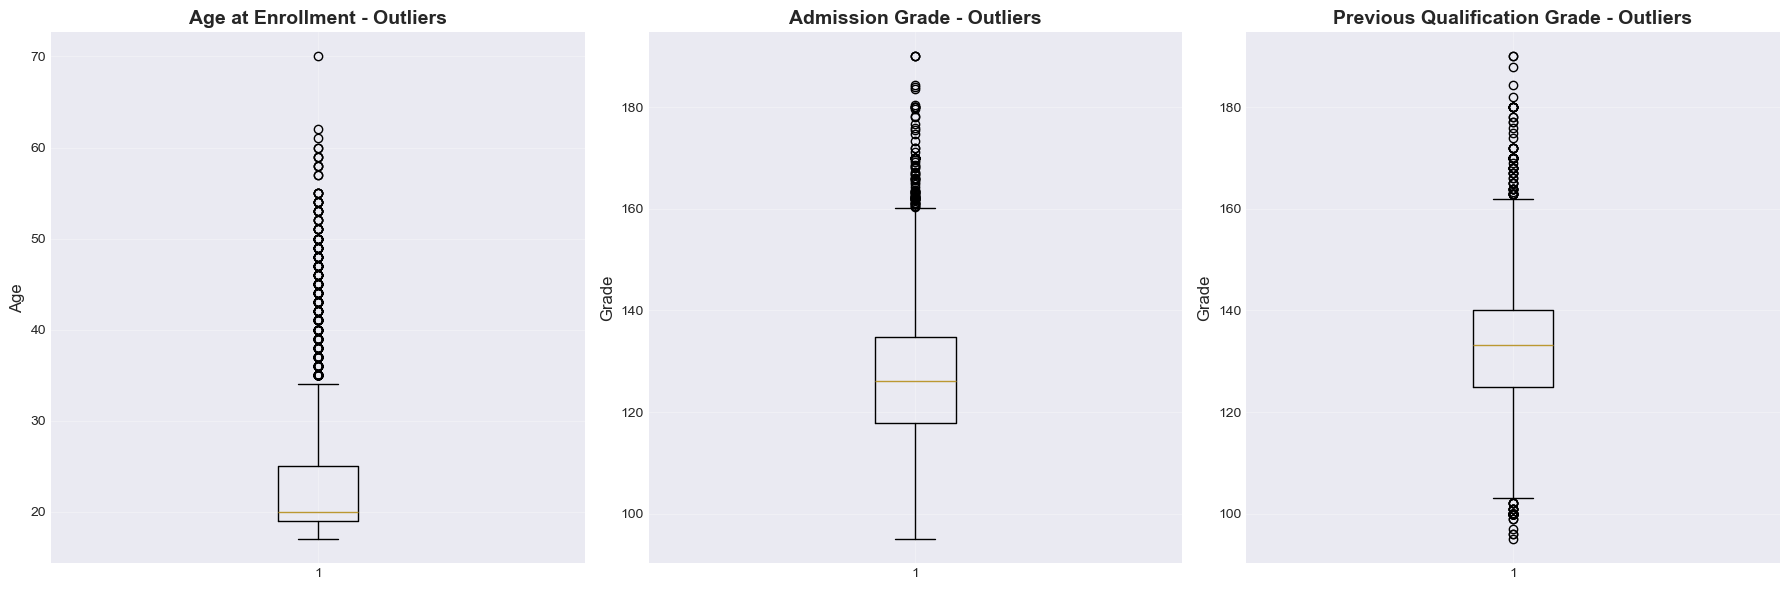

In [53]:
# ========================================
# BOXPLOTS WITH OUTLIERS
# ========================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Age at enrollment
axes[0].boxplot(df["Age at enrollment"], vert=True)
axes[0].set_title("Age at Enrollment - Outliers", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Age", fontsize=12)
axes[0].grid(alpha=0.3)

# Admission grade
axes[1].boxplot(df["Admission grade"], vert=True)
axes[1].set_title("Admission Grade - Outliers", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Grade", fontsize=12)
axes[1].grid(alpha=0.3)

# Previous qualification grade
axes[2].boxplot(df["Previous qualification (grade)"], vert=True)
axes[2].set_title("Previous Qualification Grade - Outliers", fontsize=14, fontweight="bold")
axes[2].set_ylabel("Grade", fontsize=12)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()




In [55]:
print("="*80)
print("OUTLIER DECISION")
print("="*80)
print("Based on the analysis:")
print(f"- We found {len(outliers_age)} outliers in 'Age at enrollment'.")
print("- These outliers correspond to older (mature) students.")
print("\nDECISION: We keep these outliers because they represent valid edge cases.")
print("(We do not remove them, as that would eliminate an important segment of the population.)")


OUTLIER DECISION
Based on the analysis:
- We found 441 outliers in 'Age at enrollment'.
- These outliers correspond to older (mature) students.

DECISION: We keep these outliers because they represent valid edge cases.
(We do not remove them, as that would eliminate an important segment of the population.)
